In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

exercice 1

In [3]:
housing = fetch_california_housing()

X = housing.data
y = housing.target

In [4]:
df = pd.DataFrame(X, columns=housing.feature_names)
df["MedHouseVal"] = y

In [5]:
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [6]:
print(df.shape)

(20640, 9)


In [7]:
print(df.dtypes)

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


In [8]:
print("Moyenne :")
print(df.mean())

print("\nMédiane :")
print(df.median())

print("\nVariance :")
print(df.var())

Moyenne :
MedInc            3.870671
HouseAge         28.639486
AveRooms          5.429000
AveBedrms         1.096675
Population     1425.476744
AveOccup          3.070655
Latitude         35.631861
Longitude      -119.569704
MedHouseVal       2.068558
dtype: float64

Médiane :
MedInc            3.534800
HouseAge         29.000000
AveRooms          5.229129
AveBedrms         1.048780
Population     1166.000000
AveOccup          2.818116
Latitude         34.260000
Longitude      -118.490000
MedHouseVal       1.797000
dtype: float64

Variance :
MedInc         3.609323e+00
HouseAge       1.583963e+02
AveRooms       6.121533e+00
AveBedrms      2.245915e-01
Population     1.282470e+06
AveOccup       1.078700e+02
Latitude       4.562293e+00
Longitude      4.014139e+00
MedHouseVal    1.331615e+00
dtype: float64


In [9]:
corr = df.corr()

print(corr)

               MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc       1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge    -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms     0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms   -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population   0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup     0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
Latitude    -0.079809  0.011173  0.106389   0.069721   -0.108785  0.002366   
Longitude   -0.015176 -0.108197 -0.027540   0.013344    0.099773  0.002476   
MedHouseVal  0.688075  0.105623  0.151948  -0.046701   -0.024650 -0.023737   

             Latitude  Longitude  MedHouseVal  
MedInc      -0.079809  -0.015176     0.688075  
HouseAge     0.011173  -0.108197     0.105623  
AveRooms     0.106389  -0.027540     0.151948  
AveBedrms    0.069721   0.0

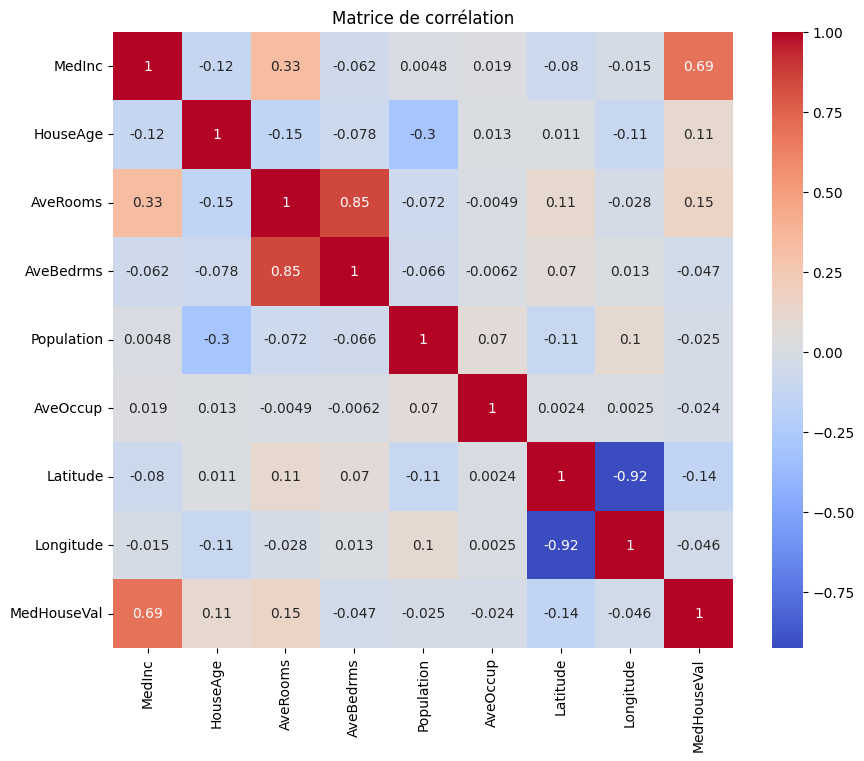

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

In [11]:
corr_target = corr["MedHouseVal"].sort_values(ascending=False)

print(corr_target)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


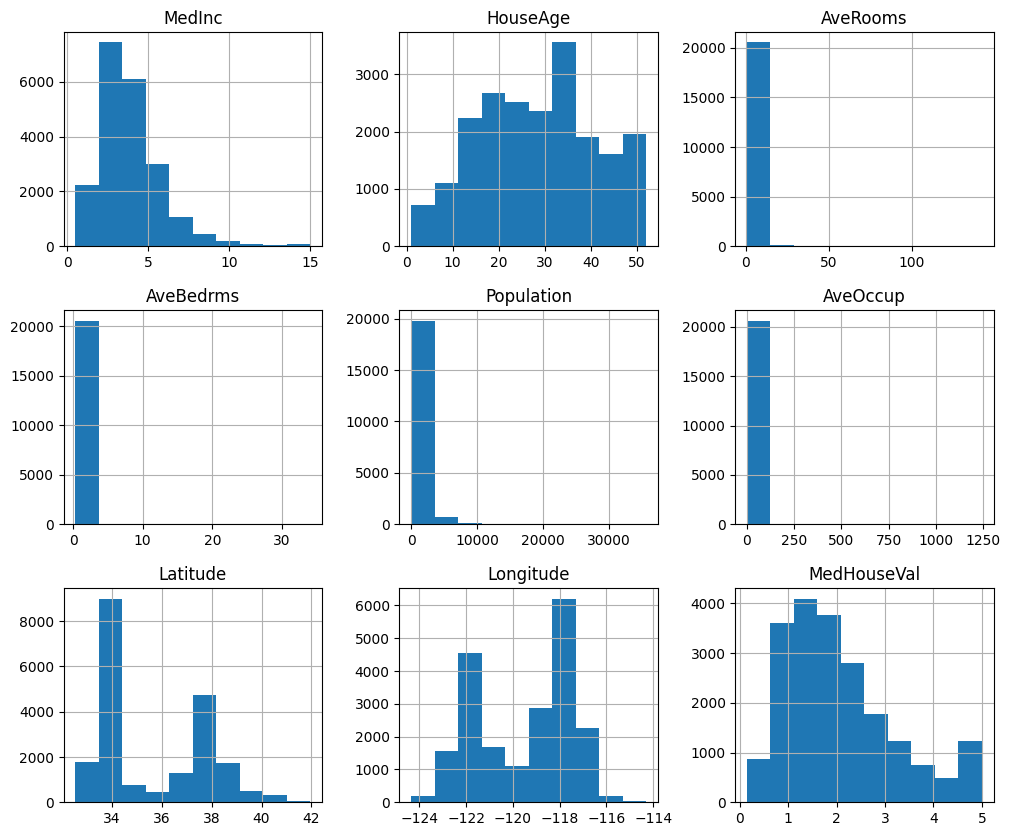

In [12]:
df.hist(figsize=(12,10))
plt.show()

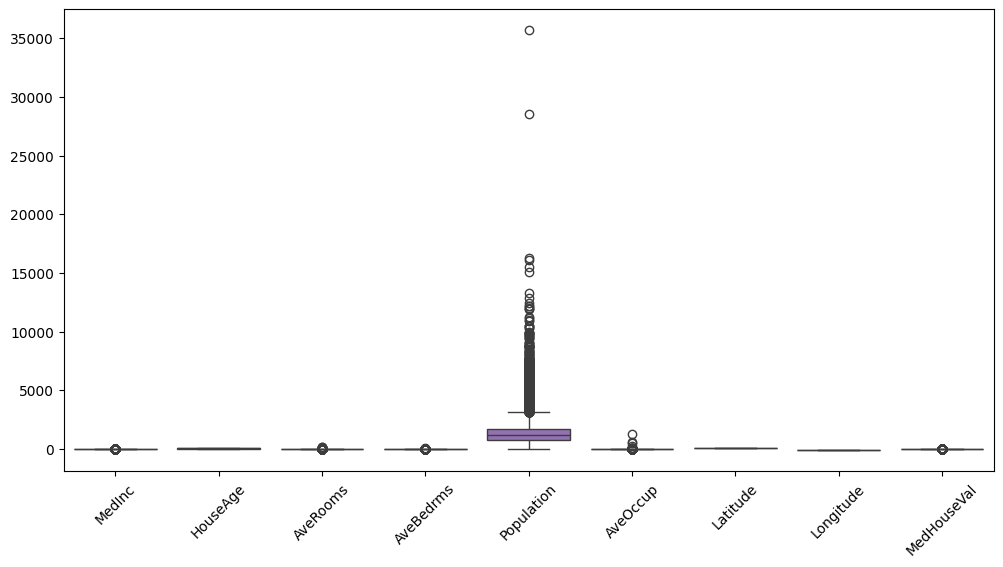

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

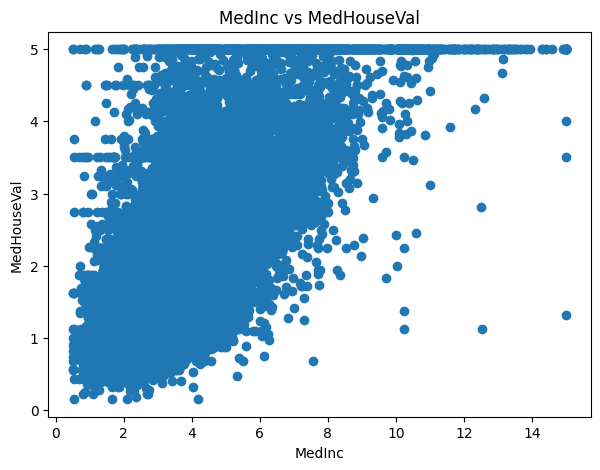

In [14]:
plt.figure(figsize=(7,5))
plt.scatter(df["MedInc"], df["MedHouseVal"])
plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")
plt.title("MedInc vs MedHouseVal")
plt.show()

exercice 2

In [15]:
print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [16]:
print(df.duplicated().sum())

0


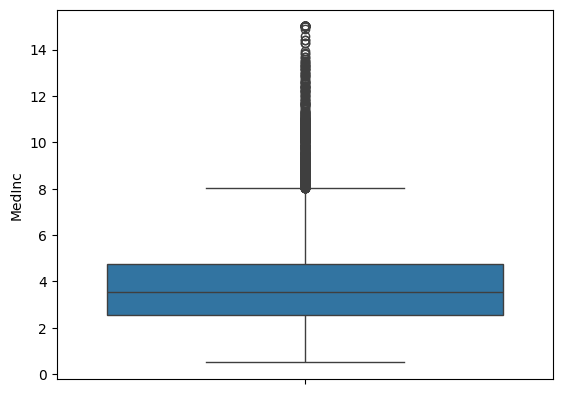

In [17]:
sns.boxplot(df["MedInc"])
plt.show()

In [18]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

4-la normalisation aide la descente de gradient à converger plus rapidement et évite qu’une variable domine les autres à cause de son échelle.

exercice 3

In [20]:
def simple_linear_regression(X, y):

    x_mean = np.mean(X)
    y_mean = np.mean(y)

    b1 = np.sum((X - x_mean)*(y - y_mean)) / np.sum((X - x_mean)**2)

    b0 = y_mean - b1*x_mean

    return b0, b1

In [21]:
x_simple = df["MedInc"].values
y_simple = df["MedHouseVal"].values

b0, b1 = simple_linear_regression(x_simple, y_simple)

print("b0 =", b0)
print("b1 =", b1)

b0 = 0.4508557670326805
b1 = 0.4179384920189625


In [22]:
y_pred_simple = b0 + b1*x_simple

exercice 4

In [23]:
def normal_equation(X, y):

    X_b = np.c_[np.ones((X.shape[0],1)), X]

    theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

    return theta

In [24]:
theta_normal = normal_equation(X_train_scaled, y_train)

print(theta_normal)

[ 2.07194694  0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772
 -0.0408291  -0.89692888 -0.86984178]


In [25]:
def compute_cost(X, y, theta):

    m = len(y)

    predictions = X.dot(theta)

    cost = (1/(2*m)) * np.sum((predictions - y)**2)

    return cost

exercice 5

In [26]:
def batch_gradient_descent(X, y, alpha=0.1, iterations=1000):

    m, n = X.shape

    theta = np.zeros(n)

    costs = []

    for i in range(iterations):

        gradients = (1/m) * X.T.dot(X.dot(theta) - y)

        theta = theta - alpha * gradients

        cost = compute_cost(X, y, theta)

        costs.append(cost)

    return theta, costs

In [27]:
X_train_b = np.c_[np.ones((X_train_scaled.shape[0],1)), X_train_scaled]
X_test_b = np.c_[np.ones((X_test_scaled.shape[0],1)), X_test_scaled]

In [28]:
theta_batch, costs_batch = batch_gradient_descent(
    X_train_b,
    y_train.values,
    alpha=0.1,
    iterations=1000
)

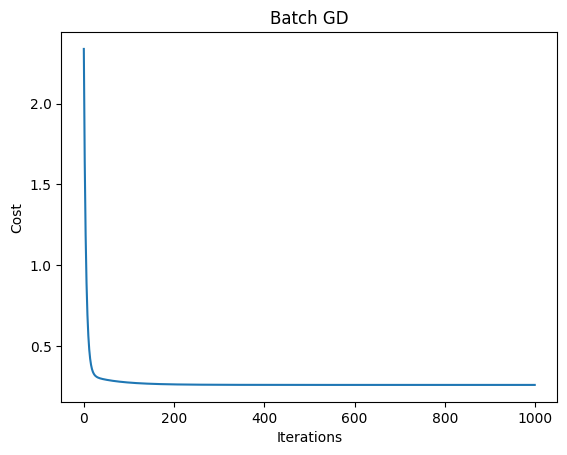

In [29]:
plt.plot(costs_batch)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Batch GD")
plt.show()

exercice 6

In [31]:
def stochastic_gradient_descent(X, y, alpha=0.01, epochs=50):

    m, n = X.shape

    theta = np.zeros(n)

    costs = []

    for epoch in range(epochs):

        for i in range(m):

            xi = X[i:i+1]
            yi = y[i]

            gradient = xi.T.dot(xi.dot(theta) - yi)

            theta = theta - alpha * gradient.flatten()

        cost = compute_cost(X, y, theta)

        costs.append(cost)

    return theta, costs

exercice 7

In [32]:
def mini_batch_gradient_descent(
    X,
    y,
    alpha=0.01,
    iterations=100,
    batch_size=32
):

    m, n = X.shape

    theta = np.zeros(n)

    costs = []

    for iteration in range(iterations):

        indices = np.random.permutation(m)

        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):

            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            gradients = (1/len(y_batch)) * X_batch.T.dot(
                X_batch.dot(theta) - y_batch
            )

            theta = theta - alpha * gradients

        cost = compute_cost(X, y, theta)

        costs.append(cost)

    return theta, costs

exercice 8

In [33]:
def mse(y_true, y_pred):

    return np.mean((y_true - y_pred)**2)


def rmse(y_true, y_pred):

    return np.sqrt(mse(y_true, y_pred))


def r2(y_true, y_pred):

    ss_res = np.sum((y_true - y_pred)**2)

    ss_tot = np.sum((y_true - np.mean(y_true))**2)

    return 1 - (ss_res/ss_tot)

exercice 9

In [34]:
y_pred_batch = X_test_b.dot(theta_batch)

In [35]:
print("MSE :", mse(y_test, y_pred_batch))
print("RMSE :", rmse(y_test, y_pred_batch))
print("R2 :", r2(y_test, y_pred_batch))

MSE : 0.5559984462926858
RMSE : 0.745653033449664
R2 : 0.5757061684367721


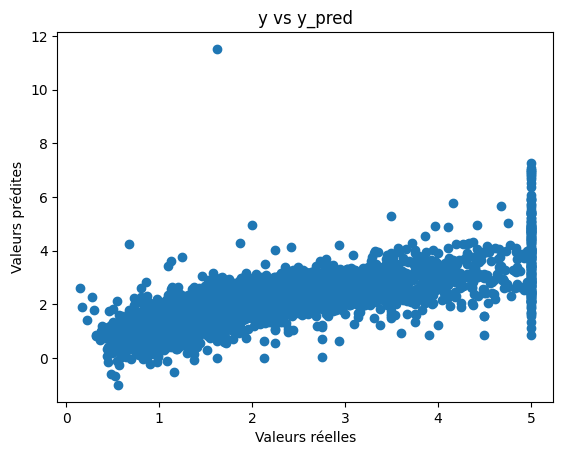

In [36]:
plt.scatter(y_test, y_pred_batch)

plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")

plt.title("y vs y_pred")

plt.show()

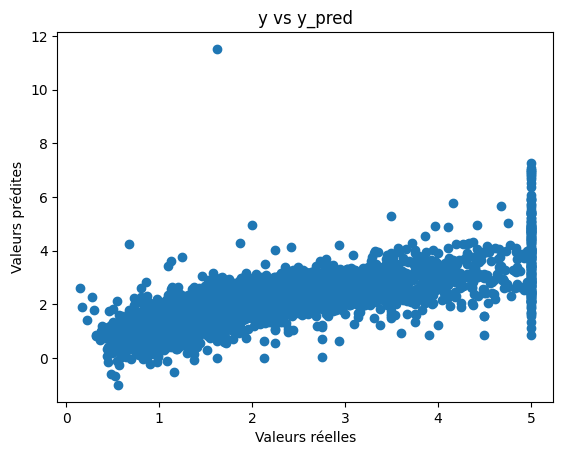

In [37]:
plt.scatter(y_test, y_pred_batch)

plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")

plt.title("y vs y_pred")

plt.show()

Réponses d’analyse

1) Impact du learning rate
α trop grand → divergence
α trop petit → convergence lente.

2) Quelle méthode est la plus rapide ?

Équation normale :
rapide pour petits datasets
solution exacte
SGD :
plus rapide sur grands datasets
mais plus bruité.

3) Quelle méthode est la plus précise ?

En général :
Batch GD et équation normale donnent des résultats proches.
L’équation normale donne souvent la solution exacte.

4) Quel modèle généralise mieux ?

Le meilleur modèle est celui qui :
a de bonnes performances sur TRAIN ET TEST,
évite l’overfitting.

exercice 10

In [38]:
top3 = corr["MedHouseVal"].abs().sort_values(
    ascending=False
).index[1:4]

print(top3)

Index(['MedInc', 'AveRooms', 'Latitude'], dtype='str')


In [39]:
X_top3 = df[top3]

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_top3,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
X_top3 = df[top3]

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_top3,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
y_pred = model.predict(X_test_scaled)

In [44]:
print("Intercept :", model.intercept_)

print("Coefficients :")

print(model.coef_)

Intercept : 2.071946937378881
Coefficients :
[ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]


In [45]:
mse_sk = mean_squared_error(y_test, y_pred)

rmse_sk = np.sqrt(mse_sk)

r2_sk = r2_score(y_test, y_pred)

print("MSE :", mse_sk)
print("RMSE :", rmse_sk)
print("R2 :", r2_sk)

MSE : 0.5558915986952444
RMSE : 0.7455813830127764
R2 : 0.5757877060324508
